# Анализ системы метрик приложения

Приложение Procrastinate Pro+ предоставляет пользователям доступ к развлекательному контенту: видео, подкастам и блогам. Пользователи могут выбрать несколько пакетов контента. Пакеты различаются по цене, объёму и содержанию.

К началу лета в приложении появился новый вид контента — спортивный. С его помощью менеджеры стремятся расширить аудиторию, добавив в неё пользователей, которые увлекаются спортом и здоровым образом жизни.

К запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. Согласно бизнес-модели продукта, привлечение должно окупиться за первые 28 дней (4 недели).

После запуска нового контента и изменения стратегии интерес к продукту в целом вырос, но выручка начала стагнировать. Нужно разобраться, почему это происходит.

Наши задачи:
- провести анализ юнит-экономики продукта в динамике за первые 28 дней;
- разобраться в причинах стагнации выручки;
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости;
- дать рекомендации отделу маркетинга.


### Данные

В нашем распоряжении есть данные о посещениях приложения, покупках и расходах на маркетинг.
Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных

Загрузим данные и выведем основную информацию о них. Проверим, все ли значения с датами и временем событий хранятся в типе datetime, при необходимости приведем их к этому типу. Основную информацию о данных и предобработке зафиксируем в кратком промежуточном выводе.

In [1]:
# Импортируем все необходимые библиотеки
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
# Выгрузим данные из архива и сохраним их в переменные df_visits, df_orders и df_costs
df_visits = pd.read_csv("https://code.s3.yandex.net/datasets/ppro_visits.csv")
df_orders = pd.read_csv("https://code.s3.yandex.net/datasets/ppro_orders.csv")
df_costs = pd.read_csv("https://code.s3.yandex.net/datasets/ppro_costs.csv")

In [3]:
# Выведем информацию о датасете df_visits
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        161865 non-null  int64 
 1   region         161865 non-null  object
 2   device         161865 non-null  object
 3   channel        161865 non-null  object
 4   session_start  161865 non-null  object
 5   session_end    161865 non-null  object
dtypes: int64(1), object(5)
memory usage: 7.4+ MB


In [4]:
# Выведем первые строки датасета df_visits
df_visits.head()

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00


In [5]:
# Проверим df_visits на наличие дубликатов
df_visits.duplicated().sum()

0

In [6]:
# Приведем значения в столбцах session_start и session_end к типу datetime
df_visits['session_start'] = pd.to_datetime(df_visits['session_start'])
df_visits['session_end'] = pd.to_datetime(df_visits['session_end'])

In [7]:
# Выведем информацию о датасете df_orders
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   33893 non-null  int64  
 1   event_dt  33893 non-null  object 
 2   revenue   33893 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 794.5+ KB


In [8]:
# Выведем первые строки датасета df_orders
df_orders.head()

,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99


In [9]:
# Проверим df_orders на наличие дубликатов
df_orders.duplicated().sum()

0

In [10]:
# Приведем значения в столбце event_dt к типу datetime
df_orders['event_dt'] = pd.to_datetime(df_orders['event_dt'])

In [11]:
# Выведем информацию о датасете df_costs
df_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       976 non-null    object 
 1   channel  976 non-null    object 
 2   costs    976 non-null    float64
dtypes: float64(1), object(2)
memory usage: 23.0+ KB


In [12]:
# Выведем первые строки датасета df_costs
df_costs.head()

,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760


In [13]:
# Проверим df_costs на наличие дубликатов
df_costs.duplicated().sum()

0

In [14]:
# Приведем значения в столбце dt к типу datetime
df_costs['dt'] = pd.to_datetime(df_costs['dt'])

### Промежуточный вывод:

* Датафрейм `df_visits` содержит 6 столбцов и 161865 строк. Данные соответствуют описанию.
* Датафрейм `df_orders` содержит 3 столбца и 33893 строки. Данные соответствуют описанию.
* Датафрейм `df_costs` содержит 3 столбца и 976 строк. Данные соответствуют описанию.

Для удобства дальнейшего анализа значения в столбцах `session_start` и `session_end` датафрейма `df_visits`, а также столбов `event_dt` датафрейма `df_orders` и `dt` датасета `df_costs` привели к типу datetime. Все остальные значения хранятся в корректном типе данных.

Пропущенные и дублирующиеся значения в датасете отсутствуют - все столбцы заполнены полностью и без повторов.

## Подготовка данных к когортному анализу

Подготовим данные к когортному анализу с учётом того, что мы будем изучать окупаемость привлечения пользователей за первые 28 дней.

Для каждого пользователя найдём:
- дату первой сессии (дата привлечения пользователя, `first_dt`);
- канал привлечения (`first_channel`);
- стоимость привлечения пользователя (`cac`).

Результаты сохраним в новой таблице `profiles`.

In [15]:
# Найдем для каждого пользователя дату первой сессии 
df_visits['first_dt'] = df_visits.groupby('user_id')['session_start'].transform('min')

In [16]:
# Для каждого пользователя найдем дату первой сессии и первый канал привлечения
# результат сохраним в новой таблице profiles
profiles = df_visits.sort_values('session_start').groupby('user_id', as_index=False).agg(
    first_dt=('session_start', 'first'),
    first_channel=('channel', 'first'))

# Оставим в first_dt только дату, без времени
profiles['first_dt'] = pd.to_datetime(profiles['first_dt'].dt.date)

Чтобы рассчитать стоимость привлечения одного пользователя, сначала найдем сумму затрат по каналам и датам, и количество привлеченных пользователей для каждого канала.

In [17]:
# Суммируем затраты по каналам из df_costs
total_costs = df_costs.groupby(['channel','dt'])['costs'].sum().reset_index()

# Считаем количество уникальных пользователей, привлеченных по каждому каналу
unique_users_count = profiles.groupby(['first_channel','first_dt'])['user_id'].nunique().reset_index()

# Объединим затраты и количество уникальных пользователей по каналам
df_cac = pd.merge(total_costs,unique_users_count,left_on=['channel','dt'],right_on=['first_channel','first_dt'],how='left')

# Рассчитаем стоимость привлечения пользователя (CAC)
df_cac['cac'] = df_cac['costs']/df_cac['user_id']

In [18]:
# Добавим в profiles данные о дате первой сессии, первом канале привлечения пользователя и CAC
profiles = pd.merge(profiles,df_cac[['first_channel', 'first_dt','cac']],on=['first_channel','first_dt'],how='left')

Добавим к данным с событиями и покупками информацию о первом источнике привлечения и дату привлечения пользователя из созданной таблицы.

In [19]:
# Добавим полученные данные в датасет df_visits
df_visits = df_visits.merge(profiles[['user_id', 'first_dt', 'first_channel']],on='user_id',how='left')

# Удалим второй столбец с датой первой события first_dt_y и переиминуем first_dt_x
df_visits = df_visits.drop(columns='first_dt_y')
df_visits = df_visits.rename(columns={'first_dt_x': 'first_dt'})

In [20]:
# Добавим полученные данные в датасет df_orders
df_orders = df_orders.merge(profiles[['user_id', 'first_dt', 'first_channel']],on='user_id',how='left')

Теперь, рассчитаем дневной лайфтайм для каждого события или покупки и добавим в таблицу в виде целого числа.

In [21]:
# Считаем дневной лайтайм для событий
df_visits['daily_lifetime'] = (df_visits['session_start'].dt.date - df_visits['first_dt'].dt.date).dt.days

In [22]:
# Считаем дневной лайтайм для покупок
df_orders['daily_lifetime'] = (df_orders['event_dt'].dt.date - df_orders['first_dt'].dt.date).dt.days

Данные готовы для когортного анализа. Для каждого пользователя мы нашли:
* Дату первого взаимодействия с продуктом `first_dt`;
* Канал первого привлечения пользователя `first_channel`;
* Стоимость привлечения пользователя `cac`.

Полученные значения сохранили в новой таблице `profiles`, а также добавили их в `df_visits` и `df_orders`.

Также для каждого события и покупки мы рассчитали дневной лайфтайм `daily_lifetime`.


## Анализ месячной динамики основных метрик продукта

Начнем анализ с изучения динамики активности пользователей и их вовлечённости в продукт. Рассчитаем по всем данным значения DAU, MAU и Stickiness и визуализируем их. Активными будем считать всех пользователей, которые взаимодействовали с приложением.

In [24]:
# Выделяем дату из session_start для подсчета DAU
df_visits['session_start'] = pd.to_datetime(df_visits['session_start'])
df_visits['date'] = df_visits['session_start'].dt.date

# Добавляем столбец с месяцем сессии для подсчета MAU
df_visits['month'] = df_visits['session_start'].dt.to_period('M').dt.to_timestamp()

In [25]:
# Рассчитываем DAU 
dau = df_visits.groupby('date')['user_id'].nunique().reset_index()

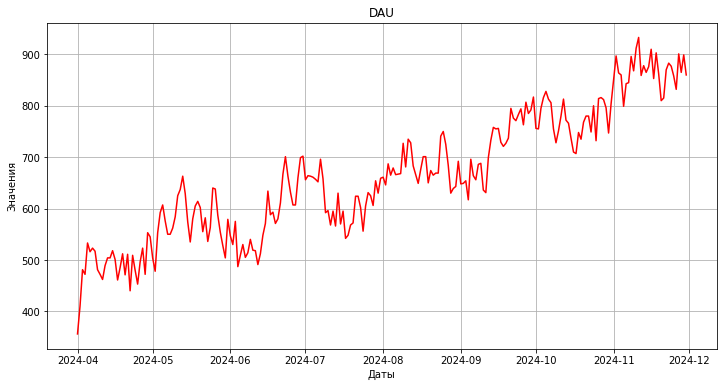

In [26]:
# Построим график для визуализации DAU
# Строим график в matplotlib
plt.figure(figsize=(12, 6))
plt.plot(dau['date'], dau['user_id'], color='red')

# Добавляем заголовок и подписи осей
plt.title('DAU')
plt.xlabel('Даты')
plt.ylabel('Значения')

# Добавляем сетку
plt.grid()

# Показываем график
plt.show()

Количество дневных активных пользователей показывает стабильный рост. Теперь, рассчитаем MAU.

In [27]:
# Рассчитываем MAU 
mau = df_visits.groupby('month')['user_id'].nunique().reset_index()

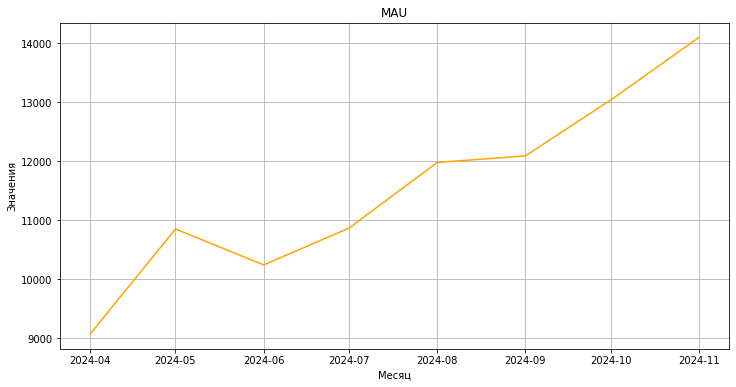

In [28]:
# Построим график для визуализации MAU
# Строим график в matplotlib
plt.figure(figsize=(12, 6))
plt.plot(mau['month'], mau['user_id'], color='orange')

# Добавляем заголовок и подписи осей
plt.title('MAU')
plt.xlabel('Месяц')
plt.ylabel('Значения')

# Добавляем сетку
plt.grid()

# Показываем график
plt.show()

MAU также стабильно рос с апреля 2024 года. Рассчитаем Stickiness.

In [29]:
# Добавляем в dau столбец с месяцем
dau['month'] = pd.to_datetime(dau['date']).dt.to_period('M').dt.to_timestamp()

# Находим среднемесячный DAU
dau_monthly_average = dau.groupby('month')['user_id'].mean().reset_index()

# Объединяем среднемесячный DAU и MAU для дальнейшего подсчета Stickiness
stickiness_table = pd.merge(mau, dau_monthly_average, how='left', on='month')

# Рассчитываем Stickiness
stickiness_table['stick'] = 100*(stickiness_table['user_id_y']/stickiness_table['user_id_x'])

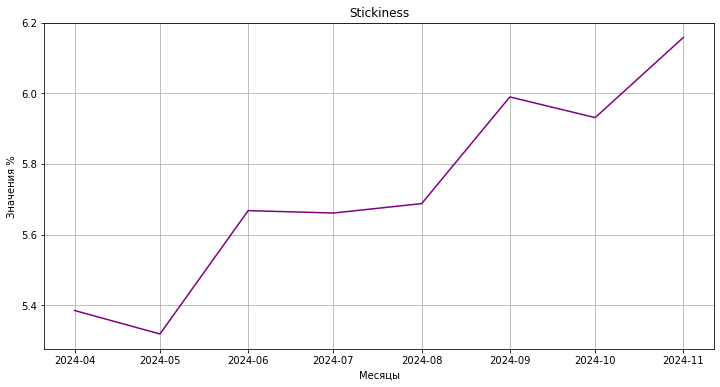

In [30]:
# Построим график для визуализации Stickiness
# Строим график в matplotlib
plt.figure(figsize=(12, 6))
plt.plot(stickiness_table['month'], stickiness_table['stick'], color='purple')

# Добавляем заголовок и подписи осей
plt.title('Stickiness')
plt.xlabel('Месяцы')
plt.ylabel('Значения %')

# Добавляем сетку
plt.grid()

# Показываем график
plt.show()

Аналогично с DAU и MAU, показатель Stickiness растет.

Теперь, в разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC).
- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.

Визуализируем метрики и сформулируем небольшой промежуточный вывод.

In [31]:
# Добавляем в profiles и df_orders столбец с месяцем привлечения для дальнейшего подсчета метрик
profiles['month'] = profiles['first_dt'].dt.to_period('M').dt.to_timestamp()
df_orders['month'] = df_orders['first_dt'].dt.to_period('M').dt.to_timestamp()

In [32]:
# Рассчитаем средний CAC в разрезе каждого месяца привлечения
avg_monthly_cac = profiles.groupby('month')['cac'].mean().reset_index()

In [33]:
# Оставим только те покупки, что были совершены за 28 дней с момента привлечения
orders_28_days = df_orders[df_orders['daily_lifetime'] < 28].copy()

In [34]:
# Суммируем выручку в разрезе каждого месяца привлечения
sum_revenue = orders_28_days.groupby('month')['revenue'].sum().reset_index()

# Считаем количество привлеченных пользователей в разрезе каждого месяца привлечения
users_count = profiles.groupby('month')['user_id'].nunique().reset_index()

# Объединяем суммарную выручку и количество привлеченных пользователей для посчета ROI
df_ltv = pd.merge(sum_revenue,users_count,on='month',how='left')

# Рассчитаем LTV в разрезе каждого месяца привлечения
df_ltv['ltv'] = df_ltv['revenue']/df_ltv['user_id']

In [35]:
# Объединим avg_monthly_cac и df_ltv для подсчета ROI
df_cac_ltv = pd.merge(avg_monthly_cac,df_ltv,on='month',how='left')

# Считаем ROI
df_cac_ltv['roi'] = ((df_cac_ltv['ltv'] - df_cac_ltv['cac'])/df_cac_ltv['cac']) * 100

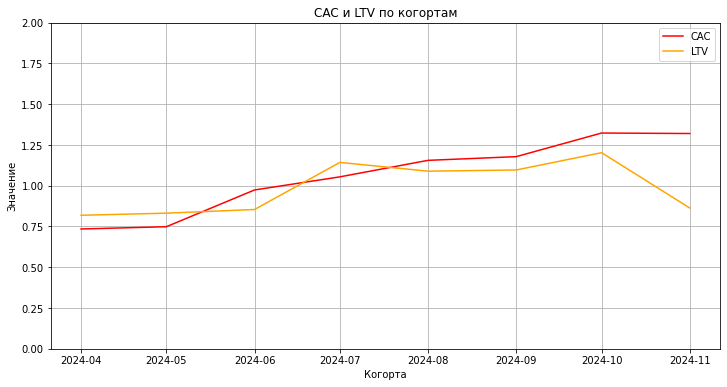

In [36]:
# Визуализируем средний CAC и LTV для всех когорт на одном графике
# Создадим графики
plt.figure(figsize=(12, 6))
plt.plot(df_cac_ltv['month'],df_cac_ltv['cac'],label='CAC',color='red')
plt.plot(df_cac_ltv['month'],df_cac_ltv['ltv'],label='LTV',color='orange')

# Добавим заголовок и подписи осей
plt.title('CAC и LTV по когортам')
plt.xlabel('Когорта')
plt.ylabel('Значение')

# Добавим границы оси y
plt.ylim(0, 2)

# Добавим сетку и легенду
plt.legend()
plt.grid()

# Выведем график
plt.show()

Стоимость привлечения пользователей для всех когорт растет с начала лета. Однако рост LTV наблюдается только в июле и затем показатель находится в режиме стагнации. За исключением июльской когорты значение САС превышает LTV. Снижение LTV для ноябрьской когорты может быть обосновано тем, что данные неполные и период наблюдения в 28 дней не соблюден.

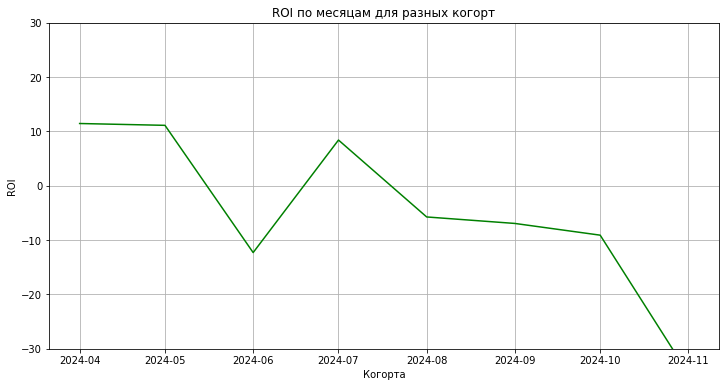

In [37]:
# Визуализируем ROI для всех когорт
# Создадим график
plt.figure(figsize=(12, 6))
plt.plot(df_cac_ltv['month'],df_cac_ltv['roi'],color='green')

# Добавим заголовок и подписи осей
plt.title('ROI по месяцам для разных когорт')
plt.xlabel('Когорта')
plt.ylabel('ROI')

# Добавим границы оси y
plt.ylim(-30, 30)

# Добавим сетку
plt.grid()

# Выведем график
plt.show()

После появления нового контента в начале лета наблюдается заметный рост CAC: если для когорт апреля–июня показатель был ниже LTV, то начиная с июля LTV не превышает затраты на привлечение. Это привело к снижению ROI. В апреле и мае показатель был выше 10%, но после изменений затраты на маркетинг не окупаются. Исключением является только июльская когорта, показатели ROI которой близки к показателям когорт апреля и мая.


### Промежуточный вывод

В ходе исследования были проанализированы показатели пользовательской активности (DAU, MAU, Stickiness), а также маркетинговой эффективности (CAC, LTV и ROI).

Ежедневная аудитория (DAU) в течение исследуемого периода показывает стабильный рост. Такой же устойчивый рост показывает и месячная аудитория (MAU). Показатель Stickiness в апреле и мае составил 5,3% и начал расти с начала лета, к ноябрю показатель достиг максимального значения 6,2%, что свидетельствует о том, что новая маркетинговая стратегия способствовала улучшению пользовательской активности.

Средняя стоимость привлечения пользователя (CAC) выросла и была выше LTV все месяцы кроме июля. Наибольшее значение CAC наблюдалось в октябре, наименьшее - в апреле и мае.

Для когорт, привлечённых до появления нового контента, показатель LTV составлял 0.83 - 0.86 и был выше стоимости привлечения. В результате ROI находился на уровне более 10%, что свидетельствует о том, что привлечение пользователей более ранних когорт окупалось.

После появления нового контента в начале лета рост LTV произошел только в июле и затем наблюдается стагнация. При этом CAC рос, что привело к снижению ROI. Минимальное значение ROI было зафиксировано для когорты июня и составило менее -10%.

**Общий вывод:**

Полученные результаты позволяют предположить, что появление нового контента оказало положительное влияние на пользовательскую активность, но отрицательное влияние на окупаемость привлечения пользователей. После его внедрения наблюдается рост пользовательской активности и снижение финансовых показателей.


## Анализ метрик в разрезе источника привлечения

Теперь необходимо разобраться, какие источники привлечения перспективны, а какие за 28 дней не окупились.

Определим самые популярные источники привлечения. Для этого:
- Посчитаем общее число привлечённых пользователей для каждого источника.
- Визуализируем динамику набора новых пользователей по дням в каждом источнике.
- Рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

In [38]:
# Считаем общее число привлеченных пользователей для каждого источника
df_grouped = profiles.groupby('first_channel')['user_id'].nunique().reset_index()

# Выведем результат
df_grouped

,first_channel,user_id
0,FaceBoom,28401
1,MediaTornado,14080
2,RocketSuperAds,14257
3,TipTop,18118


Наибольшее число пользователей пришло с каналов FaceBoom(28401) и TipTop(18118). Каналы RocketSuperAds и MediaTornado привлекли меньше пользователей - 14257 и 14080 соответственно.

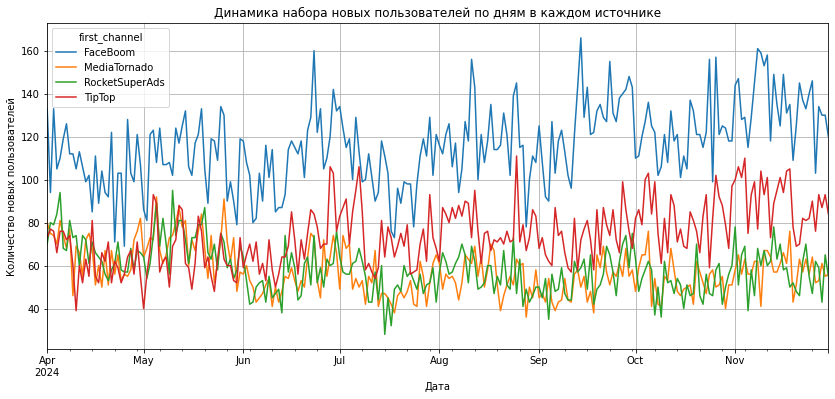

In [39]:
# Считаем количество новых пользователей по дням в каждом источнике
df_grouped_daily = profiles.groupby(['first_dt','first_channel'])['user_id'].nunique().reset_index()

# Создадим соводную таблицу
pivot = df_grouped_daily.pivot(index='first_dt',columns='first_channel',values='user_id')

# Визуализируем динамику набора новых пользователей по дням в каждом источнике
pivot.plot(figsize=(14, 6))

# Добавим заголовок и подписи осей
plt.title('Динамика набора новых пользователей по дням в каждом источнике')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')

# Добавим сетку
plt.grid()

# Выводим график
plt.show()

По графику видно, что:
1. FaceBoom - крупнейший источник привлечения.
2. TipTop занимает второе место
3. MediaTornado и RocketSuperAds показывают схожие результаты
4. После начала лета наблюдается увеличение притока пользователей из FaceBoom и TipTop, а MediaTornado и RocketSuperAds практически не меняются.

Продолжим: рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

In [40]:
# Считаем DAU по источникам привлеченеия
dau_channels = df_visits.groupby(['date','first_channel'])['user_id'].nunique().reset_index()

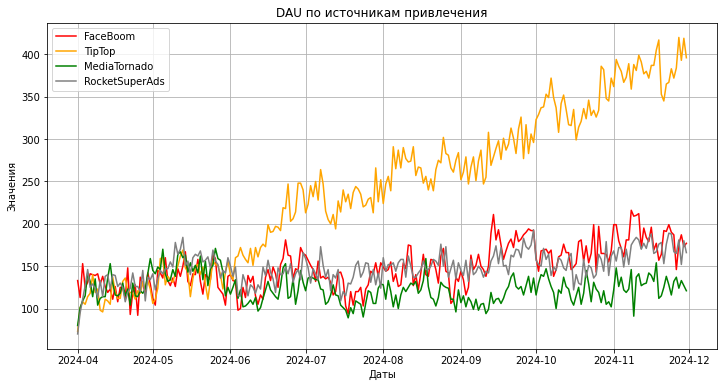

In [41]:
# Построим график для визуализации DAU по источникам привлечения
# Строим график в matplotlib
plt.figure(figsize=(12, 6))
plt.plot(dau_channels[dau_channels['first_channel'] == 'FaceBoom']['date'], dau_channels[dau_channels['first_channel'] == 'FaceBoom']['user_id'], color='red')
plt.plot(dau_channels[dau_channels['first_channel'] == 'TipTop']['date'], dau_channels[dau_channels['first_channel'] == 'TipTop']['user_id'], color='orange')
plt.plot(dau_channels[dau_channels['first_channel'] == 'MediaTornado']['date'], dau_channels[dau_channels['first_channel'] == 'MediaTornado']['user_id'], color='green')
plt.plot(dau_channels[dau_channels['first_channel'] == 'RocketSuperAds']['date'], dau_channels[dau_channels['first_channel'] == 'RocketSuperAds']['user_id'], color='gray')

# Добавляем заголовок и подписи осей
plt.title('DAU по источникам привлечения')
plt.xlabel('Даты')
plt.ylabel('Значения')

# Добавляем сетку и легенду
plt.grid()
plt.legend(['FaceBoom', 'TipTop','MediaTornado','RocketSuperAds'])

# Показываем график
plt.show()

Судя по графику количество дневных активных пользователей, привлеченных из канала TipTop, начало стремительно расти с начала лета, в то время как DAU для остальных источников привлечения либо меняется не значительно, либо остается стабильным на весь период наблюдения.

Рассчитаем и визуализируем MAU.

In [42]:
# Считаем MAU по источникам привлечения
mau_channels = df_visits.groupby(['month','first_channel'])['user_id'].nunique().reset_index(name='mau')

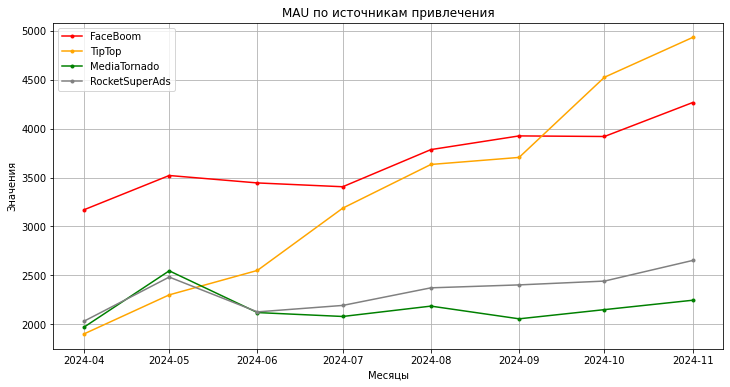

In [43]:
# Построим график для визуализации MAU по источникам привлечения
# Строим график в matplotlib
plt.figure(figsize=(12, 6))
plt.plot(mau_channels[mau_channels['first_channel'] == 'FaceBoom']['month'], mau_channels[mau_channels['first_channel'] == 'FaceBoom']['mau'], color='red',marker='.')
plt.plot(mau_channels[mau_channels['first_channel'] == 'TipTop']['month'], mau_channels[mau_channels['first_channel'] == 'TipTop']['mau'], color='orange',marker='.')
plt.plot(mau_channels[mau_channels['first_channel'] == 'MediaTornado']['month'], mau_channels[mau_channels['first_channel'] == 'MediaTornado']['mau'], color='green',marker='.')
plt.plot(mau_channels[mau_channels['first_channel'] == 'RocketSuperAds']['month'], mau_channels[mau_channels['first_channel'] == 'RocketSuperAds']['mau'], color='gray',marker='.')

# Добавляем заголовок и подписи осей
plt.title('MAU по источникам привлечения')
plt.xlabel('Месяцы')
plt.ylabel('Значения')

# Добавляем сетку и легенду
plt.grid()
plt.legend(['FaceBoom', 'TipTop','MediaTornado','RocketSuperAds'])

# Показываем график
plt.show()

MAU канала TipTop стабильно рос в течение всего периода наблюдения, в то время как показатели MAU канала FaceBoom начали немного расти только с июля. Количество месячных активных пользователей по остальным каналам остается стабильным в течение всего периода наблюдений. Также стоит заметить, что до появления спортивного контента, показатели канала FaceBoom были значительно выше других источников привлечения.

Рассчитаем и визуализируем Stickiness по каналам привлечения.

In [44]:
# Выделяем месяц из даты
dau_channels['month'] = pd.to_datetime(dau_channels['date']).dt.to_period('M').dt.to_timestamp()

# Считаем среднемесячный DAU по источникам привлечения
avg_dau_channels = dau_channels.groupby(['month', 'first_channel'])['user_id'].mean().reset_index(name='dau')

# Объединяем среднемесячный DAU и MAU 
stickiness_channels = pd.merge(avg_dau_channels,mau_channels,on=['month','first_channel'],how='left')

# Считаем Stickiness по источникам привлечения
stickiness_channels['stick'] = 100 * (stickiness_channels['dau'] / stickiness_channels['mau'])

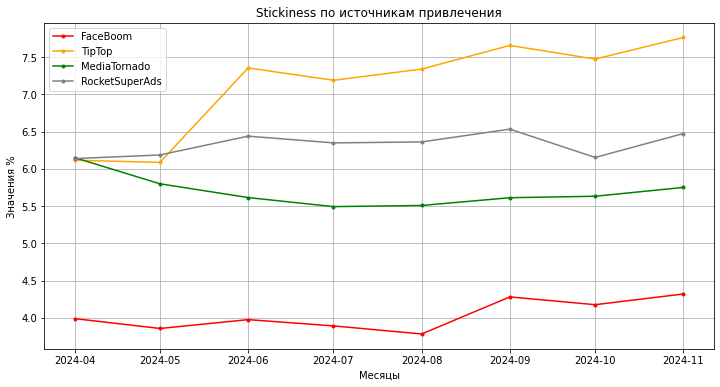

In [45]:
# Построим график для визуализации Stickiness по источникам привлечения
# Строим график в matplotlib
plt.figure(figsize=(12, 6))
plt.plot(stickiness_channels[stickiness_channels['first_channel'] == 'FaceBoom']['month'], stickiness_channels[stickiness_channels['first_channel'] == 'FaceBoom']['stick'], color='red',marker='.')
plt.plot(stickiness_channels[stickiness_channels['first_channel'] == 'TipTop']['month'], stickiness_channels[stickiness_channels['first_channel'] == 'TipTop']['stick'], color='orange',marker='.')
plt.plot(stickiness_channels[stickiness_channels['first_channel'] == 'MediaTornado']['month'], stickiness_channels[stickiness_channels['first_channel'] == 'MediaTornado']['stick'], color='green',marker='.')
plt.plot(stickiness_channels[stickiness_channels['first_channel'] == 'RocketSuperAds']['month'], stickiness_channels[stickiness_channels['first_channel'] == 'RocketSuperAds']['stick'], color='gray',marker='.')

# Добавляем заголовок и подписи осей
plt.title('Stickiness по источникам привлечения')
plt.xlabel('Месяцы')
plt.ylabel('Значения %')

# Добавляем сетку и легенду
plt.grid()
plt.legend(['FaceBoom', 'TipTop','MediaTornado','RocketSuperAds'])

# Показываем график
plt.show()

Наиболее вовлечённую аудиторию привлекает TipTop, наименее вовлечённую - FaceBoom. После начала лета для большинства источников наблюдается небольшой рост Stickiness, особенно заметный для TipTop. 

Изучим динамику изменения метрик на 28-й день в разрезе источника. Проведем анализ с выделением недельных когорт по дате привлечения. Рассчитаем и визуализируем:
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.
- Недельную динамику затрат на маркетинг по каждому источнику привлечения.
- Динамику среднего CAC, значений LTV и ROI.

По результатам проведем анализ рекламных каналов.

In [46]:
# Подготовим данные и выделим недельные когорты по дате привлечения
# Добавим новый столбец с неделей в profiles, df_visits и orders_28_days, а также в df_costs и df_orders
profiles['week'] = profiles['first_dt'].dt.to_period('W').dt.start_time
df_visits['week'] = df_visits['first_dt'].dt.to_period('W').dt.start_time
orders_28_days['week'] = orders_28_days['first_dt'].dt.to_period('W').dt.start_time
df_costs['week'] = df_costs['dt'].dt.to_period('W').dt.start_time
df_orders['week'] = df_orders['first_dt'].dt.to_period('W').dt.start_time

In [47]:
# Считаем общее количество пользователей в недельной когорте
weekly_users = profiles.groupby(['week', 'first_channel'])['user_id'].nunique().reset_index(name='weekly_users')

In [48]:
# Отберем и посчитаем пользователей, которые были активны хотя бы раз с 14 по 28 день жизни
retained_users = df_visits.query('14 <= daily_lifetime < 28').groupby(['week', 'first_channel'])['user_id'].nunique().reset_index(name='retained_users')

In [49]:
# Объединим retained_users и weekly_users
df_retention = pd.merge(weekly_users,retained_users,on=['week', 'first_channel'],how='left')

# Заполним пропуски нулем, если нет удержанных пользователей в когорте
df_retention['retained_users'] = df_retention['retained_users'].fillna(0)

In [50]:
# Считаем скользящее удержание на 14-й день с момента привлечения для недельных когорт
df_retention['rolling_retention'] = (df_retention['retained_users'] / df_retention['weekly_users'] )* 100

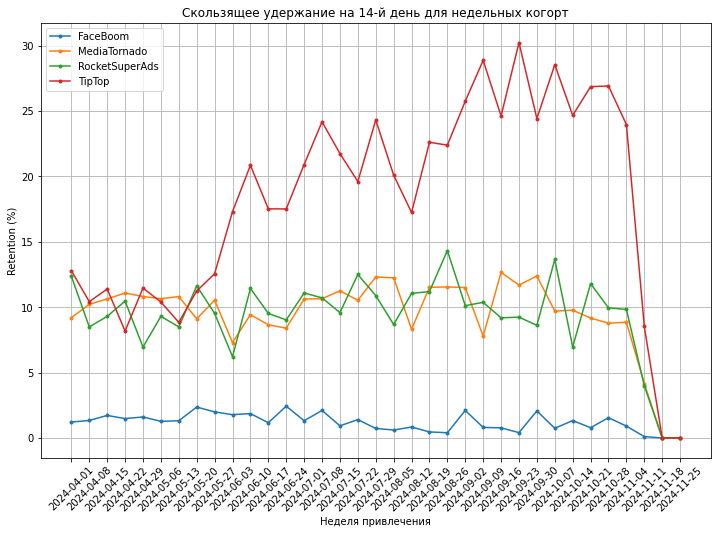

In [51]:
# Визуализируем скользящее удержание на 14-й день с момента привлечения для недельных когорт
# Создадим сводную таблицу
pivot_retention = df_retention.pivot(index='week',columns='first_channel',values='rolling_retention')

# Строим график
plt.figure(figsize=(12, 8))

for channel in pivot_retention.columns:
    plt.plot(pivot_retention.index.astype(str),pivot_retention[channel],marker='.',label=channel)

# Добавим заголовок и подписи осей
plt.title('Скользящее удержание на 14-й день для недельных когорт')
plt.xlabel('Неделя привлечения')
plt.ylabel('Retention (%)')

# Добавим легенду и сетку
plt.legend()
plt.grid()

# Добавим поворот подписей по оси Х
plt.xticks(rotation=45)

# Выведем график
plt.show()

С начала лета канал TipTop показывает стабильный рост удержания пользователей с 14 по 28 дни. Остальные источники привлечения остаются стабильными на весь период анализа. Стоит отметить, что показатель канала FaceBoom был крайне низким еще до появления нового контента и не изменился после изменений. Падение показтеля у всех каналов в ноябре вероятно связан с тем, что не достаточно данных за период в 28 дней.

In [52]:
# Считаем количество пользователей, совершивших покупку в течение первых 28 дней
# Для этого будем использовать созданный ранее датасет orders_28_days
buyers = orders_28_days.groupby(['week','first_channel'])['user_id'].nunique().reset_index(name='buyers')

In [53]:
# Объеденим размер когорт и количество пользователей, сделавших покупку
conversion = pd.merge(weekly_users,buyers,on=['week','first_channel'],how='left')

# Заполним пропуски нулем
conversion['buyers'] = conversion['buyers'].fillna(0)

# Считаем конверсию в покупку
conversion['cr'] = (conversion['buyers'] / conversion['weekly_users']) * 100

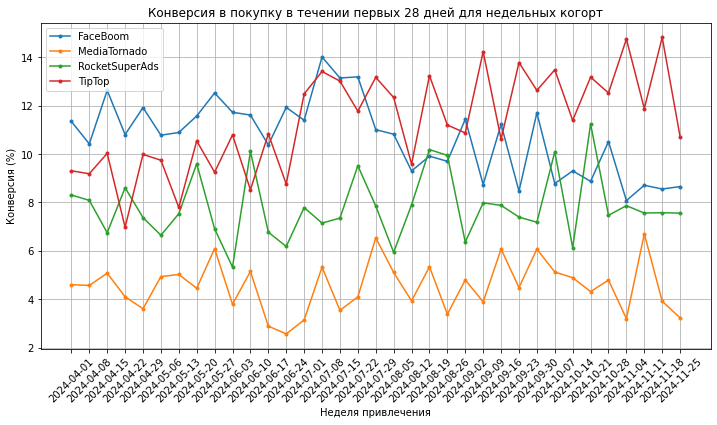

In [54]:
# Визуализируем конверсию в покупку для недельных когорт
# Создадим сводную таблицу
pivot_conversion = conversion.pivot(index='week',columns='first_channel',values='cr')

# Строим график
plt.figure(figsize=(12, 6))

for channel in pivot_conversion.columns:
    plt.plot(pivot_conversion.index.astype(str),pivot_conversion[channel],marker='.',label=channel)

# Добавим заголовок и подписи осей
plt.title('Конверсия в покупку в течении первых 28 дней для недельных когорт')
plt.xlabel('Неделя привлечения')
plt.ylabel('Конверсия (%)')

# Добавим легенду и сетку
plt.legend()
plt.grid()

# Добавим поворот подписей по оси Х
plt.xticks(rotation=45)

# Выведем график
plt.show()

Аналогично с предыдущими метриками, канал TipTop показывает рост с начала лета. В то же время, показатели канала FaceBoom падают. Конверсия остальных каналов остается стабильной в течение всего периода наблюдения. 

In [55]:
# Считаем недельные затраты на маркетинг по каждому источнику привлечения
weekly_costs = df_costs.groupby(['week','channel'])['costs'].sum().reset_index()

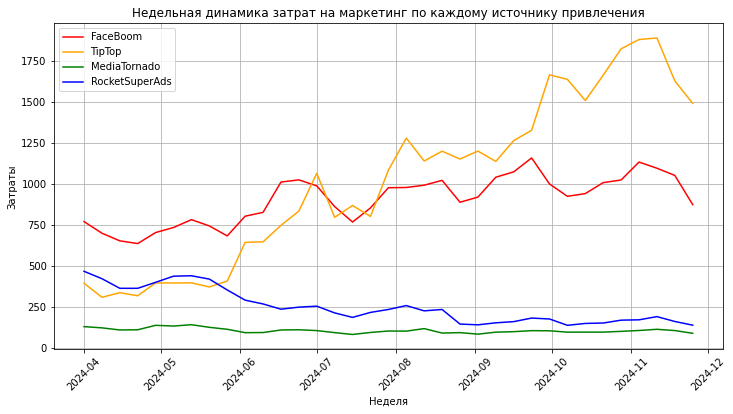

In [56]:
# Визуализируем недельную динамику затрат на маркетинг по каждому источнику привлечения
# Строим график
plt.figure(figsize=(12, 6))
plt.plot(weekly_costs[weekly_costs['channel'] == 'FaceBoom']['week'], weekly_costs[weekly_costs['channel'] == 'FaceBoom']['costs'], color='red')
plt.plot(weekly_costs[weekly_costs['channel'] == 'TipTop']['week'], weekly_costs[weekly_costs['channel'] == 'TipTop']['costs'], color='orange')
plt.plot(weekly_costs[weekly_costs['channel'] == 'MediaTornado']['week'], weekly_costs[weekly_costs['channel'] == 'MediaTornado']['costs'], color='green')
plt.plot(weekly_costs[weekly_costs['channel'] == 'RocketSuperAds']['week'], weekly_costs[weekly_costs['channel'] == 'RocketSuperAds']['costs'], color='blue')

# Добавим заголовок и подписи осей
plt.title('Недельная динамика затрат на маркетинг по каждому источнику привлечения')
plt.xlabel('Неделя')
plt.ylabel('Затраты')

# Добавим легенду и сетку
plt.legend(['FaceBoom', 'TipTop','MediaTornado','RocketSuperAds'])
plt.grid()

# Добавим поворот подписей по оси Х
plt.xticks(rotation=45)

# Выведем график
plt.show()

Зартраты на маркетинг для канала TipTop выросли с июня. Затраты на другие каналы привлечения менялись не значительно.

In [57]:
# Считаем средний CAC для недельных когорт по источникам привлечения
# Объединим недельные затраты (weekly_costs) и размеры недельных когорт (weekly_users)
df_cac_weekly = pd.merge(weekly_costs,weekly_users,left_on=['week','channel'],right_on=['week','first_channel'])

# Рассчитаем стоимость привлечения пользователя (CAC)
df_cac_weekly['cac'] = df_cac_weekly['costs']/df_cac_weekly['weekly_users']

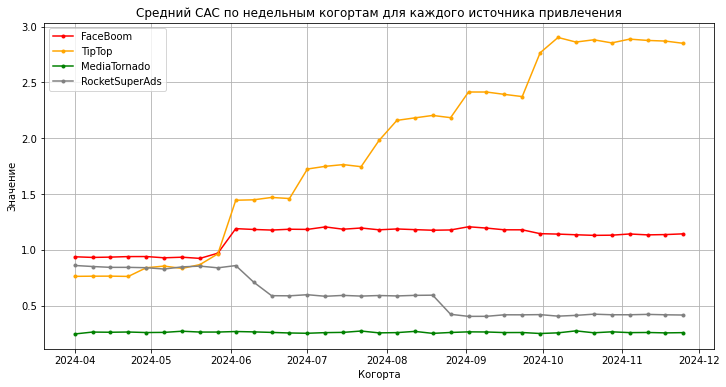

In [58]:
# Визуализируем средний CAC для недельных когорт
# Создадим графики
plt.figure(figsize=(12, 6))
plt.plot(df_cac_weekly[df_cac_weekly['first_channel'] == 'FaceBoom']['week'], df_cac_weekly[df_cac_weekly['first_channel'] == 'FaceBoom']['cac'], color='red',marker='.')
plt.plot(df_cac_weekly[df_cac_weekly['first_channel'] == 'TipTop']['week'], df_cac_weekly[df_cac_weekly['first_channel'] == 'TipTop']['cac'], color='orange',marker='.')
plt.plot(df_cac_weekly[df_cac_weekly['first_channel'] == 'MediaTornado']['week'], df_cac_weekly[df_cac_weekly['first_channel'] == 'MediaTornado']['cac'], color='green',marker='.')
plt.plot(df_cac_weekly[df_cac_weekly['first_channel'] == 'RocketSuperAds']['week'], df_cac_weekly[df_cac_weekly['first_channel'] == 'RocketSuperAds']['cac'], color='gray',marker='.')

# Добавим заголовок и подписи осей
plt.title('Средний CAC по недельным когортам для каждого источника привлечения')
plt.xlabel('Когорта')
plt.ylabel('Значение')

# Добавим сетку и легенду
plt.legend(['FaceBoom', 'TipTop','MediaTornado','RocketSuperAds'])
plt.grid()

# Выведем график
plt.show()

Средний CAC для недельных когорт канала TipTop начал расти с начала лета, в то время как САС канала FaceBoom немного вырос в июне и затем оставался на том же уровне в течение всех последующих месяцев. Показатели канала RocketSuperAds, в свою очередь, с начала лета начали снижаться и находились в состоянии стагнации с сентября. Затраты на канал MediaTornado никак не менялись в течение всего периода.

In [59]:
# Считаем LTV для недельных когорт для каждого источника привлечения
# Суммируем выручку для недельных когорт в первые 28 дней
sum_revenue_weekly = orders_28_days.groupby(['week','first_channel'])['revenue'].sum().reset_index()

# Объединяем суммарную недельную выручку и размеры недельных когорт
df_ltv_weekly = pd.merge(sum_revenue_weekly,weekly_users,on=['week','first_channel'],how='left')

# Рассчитаем LTV недельных корт для каждого источника привлечения
df_ltv_weekly['ltv'] = df_ltv_weekly['revenue']/df_ltv_weekly['weekly_users']

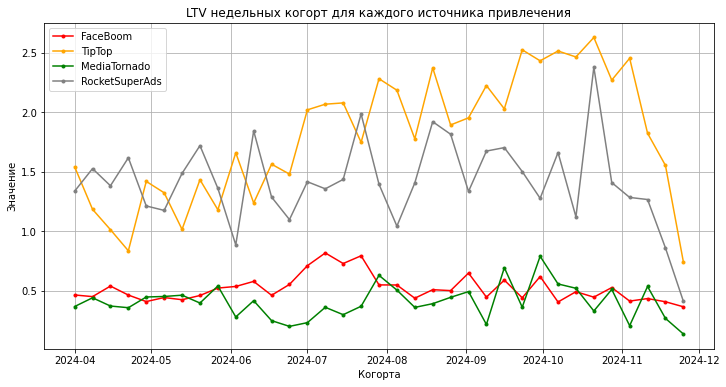

In [60]:
# Визуализируем LTV для недельных когорт
# Создадим графики
plt.figure(figsize=(12, 6))
plt.plot(df_ltv_weekly[df_ltv_weekly['first_channel'] == 'FaceBoom']['week'], df_ltv_weekly[df_ltv_weekly['first_channel'] == 'FaceBoom']['ltv'], color='red',marker='.')
plt.plot(df_ltv_weekly[df_ltv_weekly['first_channel'] == 'TipTop']['week'], df_ltv_weekly[df_ltv_weekly['first_channel'] == 'TipTop']['ltv'], color='orange',marker='.')
plt.plot(df_ltv_weekly[df_ltv_weekly['first_channel'] == 'MediaTornado']['week'], df_ltv_weekly[df_ltv_weekly['first_channel'] == 'MediaTornado']['ltv'], color='green',marker='.')
plt.plot(df_ltv_weekly[df_ltv_weekly['first_channel'] == 'RocketSuperAds']['week'], df_ltv_weekly[df_ltv_weekly['first_channel'] == 'RocketSuperAds']['ltv'], color='gray',marker='.')

# Добавим заголовок и подписи осей
plt.title('LTV недельных когорт для каждого источника привлечения')
plt.xlabel('Когорта')
plt.ylabel('Значение')

# Добавим сетку и легенду
plt.legend(['FaceBoom', 'TipTop','MediaTornado','RocketSuperAds'])
plt.grid()

# Выведем график
plt.show()

LTV канала TipTop начал расти для недельных когорт начала лета. LTV канала FaceBoom оказался не стабильным и в течение всего периода то падал, то рос. Показатели каналов RocketSuperAds и MediaTornado почти никак не менялись в течение всего периода и оставались на одном уровне. Падение LTV для всех когорт в конце исследуемого периода может быть связано с недостатком данных в 28 дней.

In [61]:
# Считаем ROI для недельных когорт
# Объеденяем полученные значения среднего CAC и LTV недельных когорт для каждого источника привлечения
df_ltv_cac_weekly = pd.merge(df_cac_weekly,df_ltv_weekly,on=['week','first_channel'],how='left')

# Считаем ROI
df_ltv_cac_weekly['roi'] = ((df_ltv_cac_weekly['ltv'] - df_ltv_cac_weekly['cac'])/df_ltv_cac_weekly['cac']) * 100

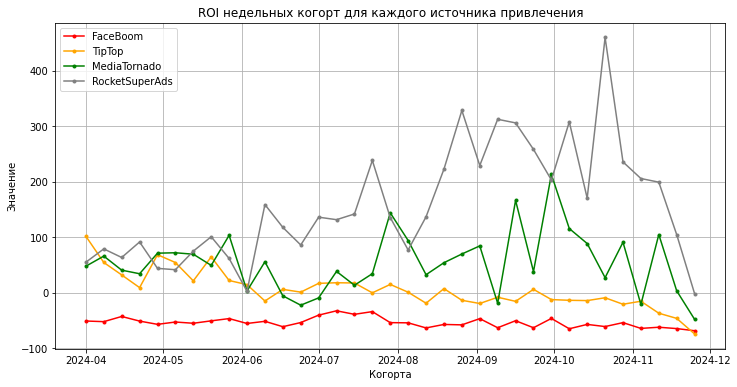

In [62]:
# Визуализируем ROI для недельных когорт
# Создадим графики
plt.figure(figsize=(12, 6))
plt.plot(df_ltv_cac_weekly[df_ltv_cac_weekly['first_channel'] == 'FaceBoom']['week'], df_ltv_cac_weekly[df_ltv_cac_weekly['first_channel'] == 'FaceBoom']['roi'], color='red',marker='.')
plt.plot(df_ltv_cac_weekly[df_ltv_cac_weekly['first_channel'] == 'TipTop']['week'], df_ltv_cac_weekly[df_ltv_cac_weekly['first_channel'] == 'TipTop']['roi'], color='orange',marker='.')
plt.plot(df_ltv_cac_weekly[df_ltv_cac_weekly['first_channel'] == 'MediaTornado']['week'], df_ltv_cac_weekly[df_ltv_cac_weekly['first_channel'] == 'MediaTornado']['roi'], color='green',marker='.')
plt.plot(df_ltv_cac_weekly[df_ltv_cac_weekly['first_channel'] == 'RocketSuperAds']['week'], df_ltv_cac_weekly[df_ltv_cac_weekly['first_channel'] == 'RocketSuperAds']['roi'], color='gray',marker='.')

# Добавим заголовок и подписи осей
plt.title('ROI недельных когорт для каждого источника привлечения')
plt.xlabel('Когорта')
plt.ylabel('Значение')

# Добавим сетку и легенду
plt.legend(['FaceBoom', 'TipTop','MediaTornado','RocketSuperAds'])
plt.grid()

# Выведем график
plt.show()

Не смотря на высокие значения LTV канала TipTop затраты на маркетинг в первые 28 дней не окупаются. До появления нового контента все затраты на маркетинг окупались, после внесения изменений ROI канала часто был отрицательным, либо близким к нулю. Затраты на канал FaceBoom не окупались как до начала лета, так и после. Затраты на привлечение пользователей из канала MediaTornado после внесения изменений зачастую окупался, за исключением нескольких когорт июня, июля, сентября и ноября. Наилучшая окупаемость затрат приходится на канал RocketSuperAds. Значения ROI сначала лета значительно выросли и находились на высоком уровне. Пиковое значение ROI (более 450%) канал достиг в середине октября.

### Промежуточный вывод: Анализ рекламных каналов

По результатам исследования наибольшее количество пользователей было привлечено через каналы FaceBoom (28 401 пользователь) и TipTop (18 118 пользователей). Каналы RocketSuperAds и MediaTornado привлекли существенно меньше пользователей - 14 257 и 14 080 соответственно. После появления нового контента в начале лета приток новых пользователей из каналов FaceBoom и особенно TipTop увеличился, тогда как динамика привлечения через RocketSuperAds и MediaTornado практически не изменилась.

Канал FaceBoom является крупнейшим источником привлечения пользователей, однако качество привлекаемой аудитории оказалось относительно низким. Несмотря на высокий объём привлечения, пользователи этого канала демонстрируют наименьшие показатели Stickiness, Retention0 и конверсии в покупку. При этом ROI оставался отрицательным как до появления нового контента, так и после него, что свидетельствует о неокупаемости затрат на привлечение пользователей через данный канал.


Канал TipTop показал наиболее заметные изменения после появления нового контента. Для пользователей, привлечённых через этот источник, наблюдался устойчивый рост DAU, MAU, Stickiness, удержания пользователей и конверсии в покупку. Одновременно с этим значительно выросли маркетинговые затраты и CAC. Несмотря на увеличение LTV, рост расходов оказался сопоставимым с ростом доходов, поэтому ROI часто находился около нуля или принимал отрицательные значения. Таким образом, высокая вовлечённость и ценность пользователей канала TipTop пока не обеспечивают стабильную окупаемость затрат на их привлечение. 
    
    
Канал MediaTornado характеризуется стабильными показателями пользовательской активности и монетизации на протяжении всего периода наблюдений. После появления нового контента существенных изменений в ключевых метриках не произошло. При этом большинство когорт демонстрировали положительный ROI, за исключением отдельных периодов, что позволяет считать данный источник в целом близким к окупаемости.
    
    
Наиболее эффективным источником привлечения оказался RocketSuperAds. Несмотря на относительно небольшие объёмы привлечения пользователей, показатели удержания, конверсии и LTV оставались стабильными, а CAC после начала лета снижался. В результате ROI существенно вырос и на протяжении большей части исследуемого периода оставался на высоком уровне, что свидетельствует о высокой эффективности данного рекламного канала.
    
    
    
Таким образом, на момент проведения анализа не вышли на устойчивый уровень окупаемости каналы FaceBoom и TipTop. Для FaceBoom причиной может быть низкое качество привлекаемой аудитории, которая демонстрирует слабую вовлечённость и конверсию в покупки. Для TipTop основной причиной является значительный рост маркетинговых расходов, который опережает рост доходов от пользователей. В то же время каналы RocketSuperAds и MediaTornado показывают более высокую эффективность использования маркетингового бюджета и демонстрируют лучшие показатели окупаемости.

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости (FaceBoom и TipTop), рассчитаем и визуализируем в виде тепловой карты значения ROI за период 8-10 недель.

Разделим данные на недельные когорты по дате привлечения, в качестве интервала наблюдений будем использовать недели.

Проверим, за какой период окупаются вложения в эти источники.

Подготовим данные к анализу периода окупаемости маркетинговых вложений и рассчитаем недельный lifetime для покупок.

In [63]:
# Считаем недельный lifetime для покупок
df_orders['weekly_lifetime'] = df_orders['daily_lifetime'] // 7

In [64]:
# Отфильтруем df_orders и оставим только данные об неокупившихся каналах
df_orders_filtered = df_orders[(df_orders['first_channel'] == 'FaceBoom') | (df_orders['first_channel'] == 'TipTop')].copy()

# Оставим только первые 10 недель жизненного цикла когорт
df_orders_filtered = df_orders_filtered.query('0 <= weekly_lifetime <= 10')

In [65]:
# Рассчитаем накопленный LTV для неокупившихся каналов
# Суммируем выручку
df_grouped_ltv = df_orders_filtered.groupby(['week','first_channel','weekly_lifetime'])['revenue'].sum().reset_index()

# Отсортируем датасет для правильного подсчета накопленной выручки
df_grouped_ltv = df_grouped_ltv.sort_values(['week', 'first_channel', 'weekly_lifetime'])

# Считаем накопленную выручку по неделям
df_grouped_ltv['cum_revenue'] = df_grouped_ltv.groupby(['week', 'first_channel'])['revenue'].cumsum()

# Объединяем накопленную выручку и размеры недельных когорт
weekly_lifetime_ltv = pd.merge(df_grouped_ltv,weekly_users,on=['week', 'first_channel'],how='left')

# Считаем накопленный LTV
weekly_lifetime_ltv['cum_ltv'] = weekly_lifetime_ltv['cum_revenue'] / weekly_lifetime_ltv['weekly_users']

In [66]:
# Рассчитаем ROI по неделям жизни в продукте
# Объеденим накопленный LTV и рассчитанный ранее средне-недельный САС
df_roi_weekly = pd.merge(weekly_lifetime_ltv,df_cac_weekly,on=['week', 'first_channel'],how='left')

# Считаем накопленный ROI
df_roi_weekly['cum_roi'] = ((df_roi_weekly['cum_ltv'] - df_roi_weekly['cac']) / df_roi_weekly['cac']) * 100

In [67]:
# Для визуализации ROI создадим 2 отдельных сводных таблицы для каждого неокупившегося канала
# Создаем pivot_table() для канала FaceBoom
pivot_faceboom = df_roi_weekly[df_roi_weekly['first_channel'] == 'FaceBoom'].pivot_table(index='week', columns='weekly_lifetime', values='cum_roi')
# Заменяем нули на пропуски для корректного отображения
pivot_faceboom[pivot_faceboom == 0] = float('nan')
pivot_faceboom.index = pivot_faceboom.index.strftime('%Y-%m-%d') # чтобы когорты отображались в правильном формате

# Создаем pivot_table() для канала TipTop
pivot_tiptop = df_roi_weekly[df_roi_weekly['first_channel'] == 'TipTop'].pivot_table(index='week', columns='weekly_lifetime', values='cum_roi')
# Заменяем нули на пропуски для корректного отображения
pivot_tiptop[pivot_tiptop == 0] = float('nan')
pivot_tiptop.index = pivot_tiptop.index.strftime('%Y-%m-%d') # чтобы когорты отображались в правильном формате

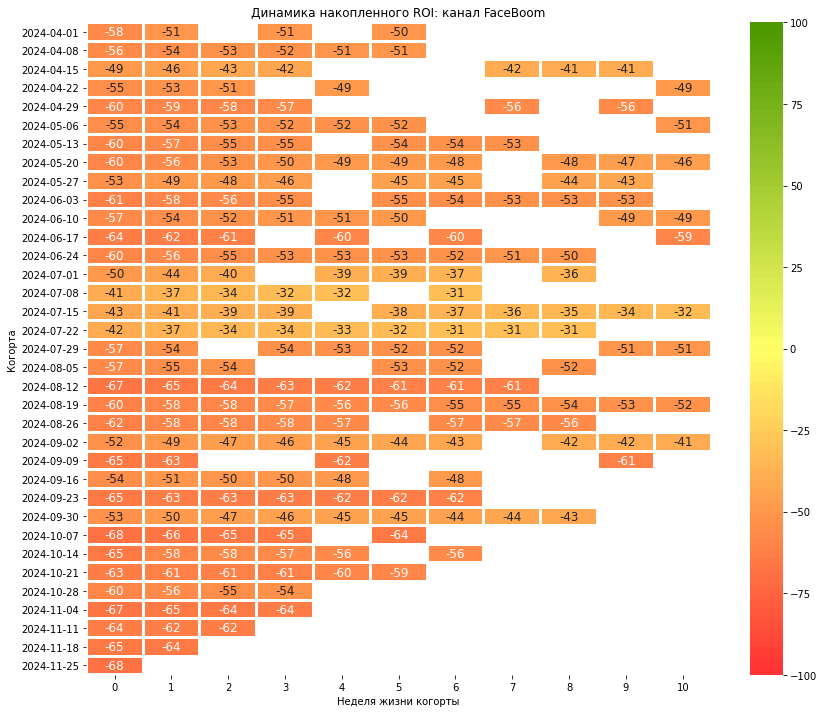

In [68]:
# Визуализируем кумулятивный ROI для канала FaceBoom
# Создадим цветовую палитру
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

# Устанавливаем размер графика
plt.rcParams['figure.figsize'] = (14, 12)

# Строим тепловую карту для канала FaceBoom
sns.heatmap(
    pivot_faceboom,
    cmap=cmap,
    annot=True,
    center=0,
    vmin=-100,
    vmax=100,
    fmt='.0f',
    linewidths=2,
    annot_kws={"size": 12})

# Добавляем подписи для осей и заголовок графика
plt.title('Динамика накопленного ROI: канал FaceBoom')
plt.xlabel('Неделя жизни когорты')
plt.ylabel('Когорта')

# Выводим график
plt.show()

Канал FaceBoom не окупился даже спустя 10 недель жизни когорт. Также мы можем увидеть пропуски во многих неделях для разных когорт, что говорит о том, что пользователи не совершали ни одной покупки в течение этих недель. Пропуски есть как в более ранних, так и в поздних когортах, а значит канал привлекает незаинтересованных пользователей и затраты на маркетинг из-за этого не окупаются.

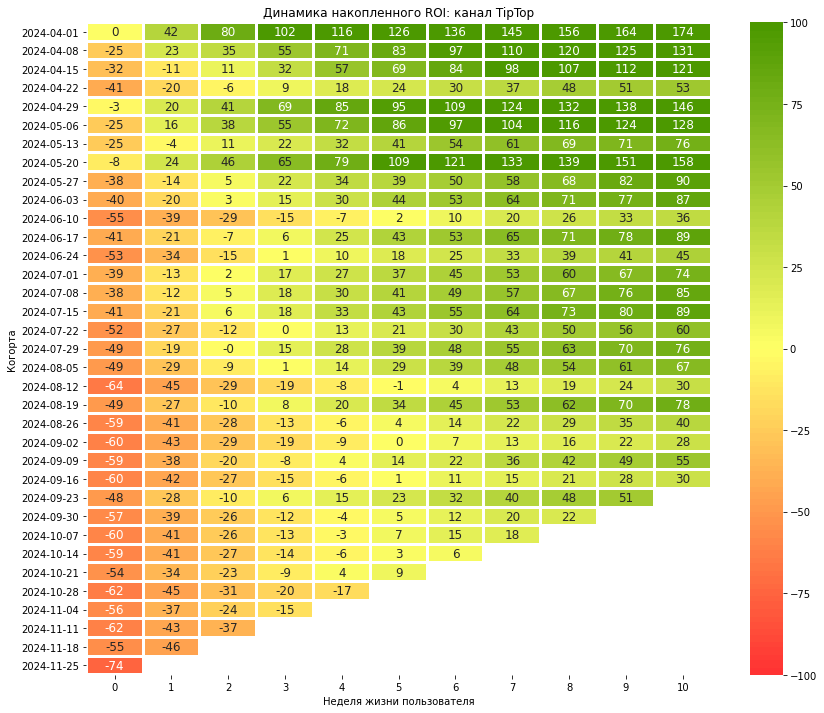

In [69]:
# Визуализируем кумулятивный ROI для канала TipTop
# Создадим цветовую палитру
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

# Устанавливаем размер графика
plt.rcParams['figure.figsize'] = (14, 12)

# Строим тепловую карту для канала FaceBoom
sns.heatmap(
    pivot_tiptop,
    cmap=cmap,
    annot=True,
    center=0,
    vmin=-100,
    vmax=100,
    fmt='.0f',
    linewidths=2,
    annot_kws={"size": 12})

# Добавляем подписи для осей и заголовок графика
plt.title('Динамика накопленного ROI: канал TipTop')
plt.xlabel('Неделя жизни пользователя')
plt.ylabel('Когорта')

# Выводим график
plt.show()

У канала TipTop более положительные показатели. Судя по графику, начиная с июня, большинство когорт не окупаются на 4 и 5 недели жизни. Однако, с 6 недели жизни все когорты, за исключением двух, окупились. 

## Выводы и рекомендации

Сформулируйте общий вывод. Зафиксируйте основные результаты и инсайты. Например, охарактеризуйте аудиторию продукта, покажите распределение маркетинговых затрат по каналам привлечения, опишите каждый канал привлечения. Делайте акцент на сильных и слабых сторонах. Укажите, какие каналы привлечения не вышли на окупаемость и по каким причинам.

Дайте рекомендации отделу маркетинга: опишите, как повысить эффективность вложений в рекламу.


## Выводы и рекомендации

### Общий вывод

Цель исследования заключалась в оценке влияния нового контента и изменений маркетинговой стратегии на пользовательскую активность, монетизацию и эффективность рекламных каналов.

Результаты анализа показали, что после запуска нового контента интерес пользователей к продукту действительно вырос. Это подтверждается устойчивым ростом показателей DAU и MAU, а также увеличением Stickiness с 5,3% до 6,2%. Пользователи стали чаще возвращаться в продукт и проводить в нём больше времени. Особенно заметные изменения наблюдались после начала лета, что позволяет связать рост пользовательской активности с появлением нового контента.

При этом рост пользовательской активности не привёл к пропорциональному росту выручки. Ухудшение показателей LTV и ROI по сравнению с весенними когортами привело к тому, что финансовый эффект оказался значительно слабее роста аудитории. Основная причина заключается в различиях между качеством аудитории, привлекаемой через разные рекламные каналы.

Наибольший объём пользователей был привлечён через FaceBoom и TipTop. Однако эффективность этих каналов существенно различается.

FaceBoom является крупнейшим источником трафика, но демонстрирует самые низкие показатели удержания, вовлечённости и конверсии в покупку. Пользователи, привлечённые через данный канал, редко совершают покупки и не обеспечивают возврат вложенных средств. Анализ долгосрочной окупаемости показал, что даже через 10 недель жизни когорт ROI остаётся отрицательным. Кроме того, во многих когортах наблюдаются периоды полного отсутствия покупок, что свидетельствует о низком качестве привлекаемой аудитории. Таким образом, FaceBoom обеспечивает большой объём установок, но привлекает пользователей с низкой вероятностью монетизации.

TipTop оказался каналом, который сильнее всего выиграл от появления нового контента. После начала лета наблюдался рост DAU, MAU, удержания, вовлечённости и конверсии в покупку. Пользователи данного канала проявляют высокий интерес к продукту и демонстрируют более высокие значения LTV. Однако одновременно с этим значительно выросли маркетинговые расходы и CAC. В результате большая часть когорт не окупалась в течение первых четырёх-пяти недель жизни. Тем не менее анализ долгосрочной окупаемости показал, что начиная примерно с шестой недели большинство когорт выходит на положительный ROI. Следовательно, данный канал способен приносить прибыль, но требует более длительного периода окупаемости.

MediaTornado показал стабильные результаты на протяжении всего периода исследования. После появления нового контента существенных изменений в поведении пользователей не произошло, однако большинство когорт демонстрировали положительный ROI. Канал обеспечивает умеренный объём привлечения пользователей и близок к устойчивой окупаемости.

Наиболее эффективным источником привлечения оказался RocketSuperAds. Несмотря на относительно небольшие объёмы привлечения пользователей, данный канал характеризуется стабильным удержанием, высокой конверсией в покупку и ростом ROI после запуска нового контента. При этом CAC снижался, что дополнительно повысило эффективность вложений. Среди всех исследуемых каналов RocketSuperAds обеспечивает наилучшее соотношение между затратами и получаемой выручкой.

Таким образом, рост интереса к продукту после запуска нового контента действительно произошёл, однако выручка не выросла пропорционально увеличению аудитории. Основная причина заключается в том, что значительная часть новых пользователей была привлечена через FaceBoom и TipTop. При этом аудитория FaceBoom обладает низким качеством и практически не монетизируется, а аудитория TipTop требует более длительного периода для достижения окупаемости. В результате общий рост пользовательской базы не привёл к сопоставимому росту финансовых показателей.


### Рекомендации отделу маркетинга

1. Сократить объём инвестиций в канал FaceBoom или провести дополнительную проверку качества трафика. Текущие показатели свидетельствуют о том, что данный канал привлекает большое количество пользователей, которые практически не совершают покупок и не окупают затраты на привлечение.

2. Продолжить работу с каналом TipTop, поскольку он привлекает наиболее вовлечённую аудиторию. Однако необходимо контролировать темпы роста маркетинговых расходов и оптимизировать рекламные кампании для снижения CAC. Также при оценке эффективности канала следует учитывать более длительный горизонт окупаемости - не менее 6 недель.

3. Увеличить долю маркетингового бюджета, направляемую в RocketSuperAds. Канал демонстрирует наиболее высокую окупаемость и обеспечивает стабильный приток качественной аудитории.
   
    
4. Сохранить присутствие в MediaTornado как в стабильном и близком к окупаемости канале. При наличии возможностей рекомендуется тестировать новые рекламные кампании для дальнейшего повышения эффективности.